In [1]:
import numpy as np
import pandas as pd
import glob, os, subprocess, vcf, pysam, shutil, sparse, yaml, sys, pickle, itertools
from Bio import Entrez, Seq, SeqIO, SeqUtils
import scipy.stats as st

# utils files are in a separate folder
os.chdir("../")
sys.path.append("utils")
from saliency_utils import *
from inSilicoMut_utils import *
from analysis_utils import *
from data_utils import *

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
model_loci = pd.read_csv("data_processing/data_utils/drug_loci.csv")

BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
output_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_full = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_v4.csv")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")
h37Rv_coords_to_gene = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/h37Rv_coords_to_gene.csv")
h37Rv_coords_to_gene_dict = dict(zip(h37Rv_coords_to_gene['pos'], h37Rv_coords_to_gene['region']))

# full_data = pd.read_csv("data_processing/samples_pass_geno_QC.csv")
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")

results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
cc_df_who = pd.read_csv("/home/sak0914/who-analysis/data/drug_CC.csv")

isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETO",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMK",
                  "Pretomanid": "PMD",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LFX",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}

df_MIC_ML = pd.read_csv("./MIC_data/MIC_ML.csv")
df_cryptic = pd.read_csv("./MIC_data/CRyPTIC_normalized.csv")

df_samples_geno = pd.read_csv("data_processing/samples_pass_geno_QC.csv")
# df_samples_geno['log_F2'] = np.log2(df_samples_geno['F2'])

genomic_data_dir = "/n/data1/hms/dbmi/farhat/rollingDB/genomic_data"

drugs_lst = ['BDQ', 'EMB', 'ETO', 'INH', 'LFX', 'MXF', 'PZA', 'RIF']
cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETO': 5, 'MXF': 0.5, 'LFX': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_WHO_catalog_variants.csv").dropna(subset='variant').reset_index(drop=True)
all_drugs_insilico_pred = pd.read_csv("supplement/insilico_pred_all.csv")
H37Rv_insilico_pred = all_drugs_insilico_pred.query("variant=='MT_H37Rv'").reset_index(drop=True)

# How are Isolates whose MICs span the CC Predicted?

In [4]:
def get_predictions_for_span_CC_isolates(drug, model_path):

    df_pred = pd.read_csv(f"{results_dir}/{model_path}/test_predictions.csv").query("Span_CC==1")
    return df_pred

In [42]:
LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                   "BOV_AFRI": "black"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }

In [105]:
df_pred_all = []

for drug in drugs_lst:

    if drug == 'PZA':
        model_path = f"{drug}_amino_acid"
    else:
        model_path = f"{drug}_lineage_amino_acid"

    cc = cc_dict[drug]
    
    df_pred = pd.read_csv(f"{results_dir}/{model_path}/test_predictions.csv").query("Span_CC==1").query("lower >= @cc/2") #.query("lower >= @cc/4 & lower <= @cc/2") #
    df_pred['Drug'] = abbr_drug_dict[drug]
    df_pred_all.append(df_pred)

df_pred_all = pd.concat(df_pred_all)
df_pred_all['y_pred_exp'] = np.exp2(df_pred_all['y_pred'])
df_pred_all = df_pred_all.merge(df_samples_geno.rename(columns={'ROLLINGDB_ID': 'Isolate'}))

In [106]:
df_pred_all.Drug.unique()

array(['Bedaquiline', 'Ethambutol', 'Isoniazid', 'Ethionamide',
       'Moxifloxacin', 'Rifampicin'], dtype=object)

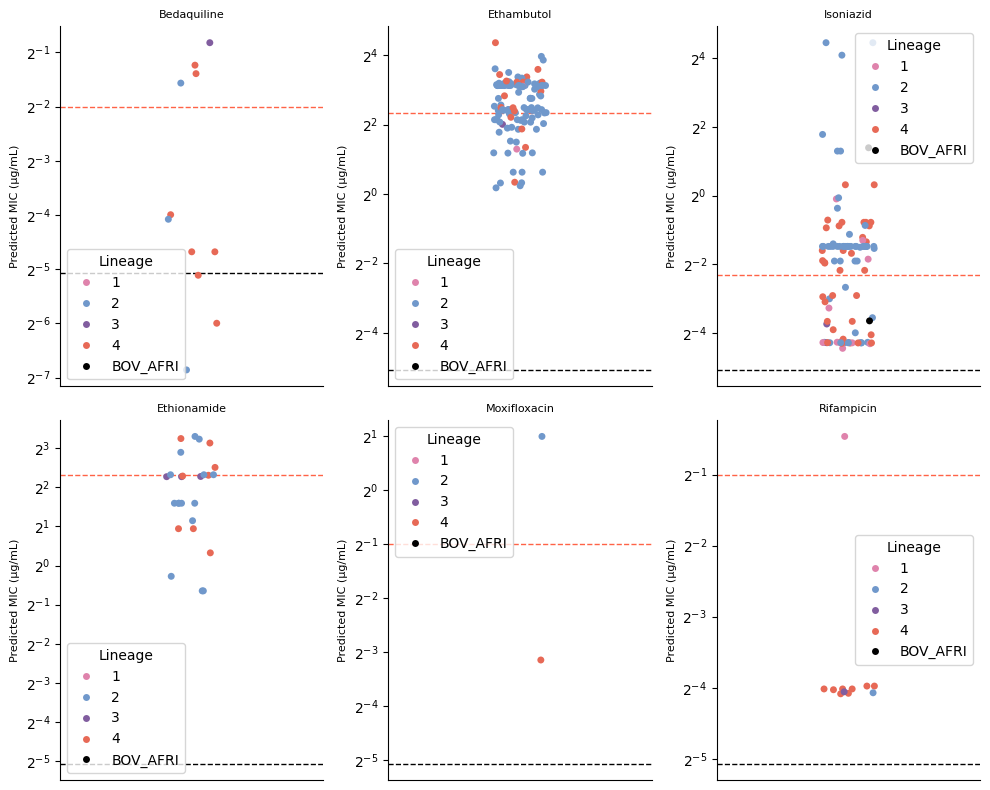

In [80]:
fig, ax = plt.subplots(2, 3, figsize=(10, 8))
ax = ax.flatten()

for i, drug in enumerate(df_pred_all.Drug.unique()):

    sns.stripplot(data=df_pred_all.query("Drug==@drug"),
                  x='Drug',
                  y='y_pred_exp',
                  log_scale=2,
                  hue='Lineage',
                  palette=LinToColor_Dict,
                  hue_order=LinToColor_Dict.keys(),
                  ax=ax[i]
                 )

    cc = cc_dict[drug_abbr_dict[drug]]
    ref_pred = H37Rv_insilico_pred.pred_MIC.values[0]

    sig_fig = 1
    ax[i].axhline(cc, label=f'CC = {cc}', color='tomato', linestyle='--', linewidth=1, zorder=0)
    ax[i].axhline(ref_pred, label=f'H37Rv = {np.round(ref_pred, sig_fig)}', color='black', linestyle='--', linewidth=1, zorder=0)
    # plt.legend(fontsize=6)
    
    ax[i].set_xticks([])
    # ax[i].set_yticks(fontsize=8)
    
    # Set the font size for y-tick labels
    plt.setp(y_ticks, fontsize=8)

    ax[i].set_xlabel('')
    ax[i].set_title(drug, fontsize=8)
    ax[i].set_ylabel('Predicted MIC (µg/mL)', fontsize=8)
    
    sns.despine()
    plt.tight_layout()

In [118]:
df_pred_all.query("Drug=='Bedaquiline' & y_pred_exp < 0.125").sort_values("y_pred_exp")#.drop_duplicates(subset=['lower', 'upper'])

,Isolate,y_test,lower,upper,Span_CC,y_pred,Drug,y_pred_exp,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage
0,SAMN37124201,-2.095420,0.156,0.312,1,-6.857486,Bedaquiline,0.008624,MICML,2.2.1,2.2.1.1.1,"beijing,mungi",lin2.2.1,NaN,0.009393,2
2,SAMN37124224,-2.095420,0.156,0.312,1,-5.996750,Bedaquiline,0.015660,MICML,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,0.005389,4
9,TN15617,-2.058894,0.160,0.320,1,-5.111932,Bedaquiline,0.028917,MICML,4.1.1,4.1.i1.2.1,xtype,NaN,4,0.027660,4
5,SAMN37124261,-2.095420,0.156,0.312,1,-4.679487,Bedaquiline,0.039024,MICML,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM,0.026825,4
6,SAMN37124262,-2.095420,0.156,0.312,1,-4.679487,Bedaquiline,0.039024,MICML,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM,0.029980,4
7,SAMN37124287,-2.095420,0.156,0.312,1,-4.079423,Bedaquiline,0.059152,MICML,2.2.2,2.2.2,"beijing,ethiopian,mungi","asia_ancestral_1,lin2.2",NaN,0.015881,2
1,SAMN37124218,-2.095420,0.156,0.312,1,-3.995299,Bedaquiline,0.062704,MICML,4.4.1.1,4.2.1.2.2.1.1,stype,NaN,4,0.008862,4


In [120]:
isolate_variants.query("ROLLINGDB_ID=='SAMN37124201' & drug=='Bedaquiline'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
6137,SAMN37124201,775639,T,C,PASS,5163.0,False,1.00,155.0,34.0,60.0,0.0,0.0,missense_variant,mmpL5,c.2842A>G,p.Ile948Val,mmpL5_p.Ile948Val,Bedaquiline,4) Not assoc w R - Interim
6139,SAMN37124201,776100,G,A,PASS,5212.0,False,1.00,148.0,35.0,60.0,0.0,0.0,missense_variant,mmpL5,c.2381C>T,p.Thr794Ile,mmpL5_p.Thr794Ile,Bedaquiline,4) Not assoc w R - Interim
6141,SAMN37124201,776182,C,T,PASS,4596.0,False,1.00,132.0,35.0,60.0,0.0,0.0,missense_variant,mmpL5,c.2299G>A,p.Asp767Asn,mmpL5_p.Asp767Asn,Bedaquiline,5) Not assoc w R
6143,SAMN37124201,778979,C,A,PASS,4317.0,False,1.00,126.0,34.0,59.0,0.0,0.0,intergenic_region,mmpS5-Rv0678,n.778979C>A,NaN,mmpS5_c.-74G>T,Bedaquiline,4) Not assoc w R - Interim
6146,SAMN37124201,779414,T,G,Amb,4014.0,False,0.55,141.0,35.0,60.0,0.0,0.0,missense_variant,Rv0678,c.425T>G,p.Leu142Arg,Rv0678_p.Leu142Arg,Bedaquiline,3) Uncertain significance
6169,SAMN37124201,2223293,T,C,PASS,5729.0,False,1.00,162.0,35.0,60.0,0.0,0.0,intergenic_region,Rv1979c-mpt64,n.2223293T>C,NaN,Rv1979c_c.-129A>G,Bedaquiline,4) Not assoc w R - Interim
6176,SAMN37124201,3625065,T,G,PASS,4066.0,False,1.00,118.0,34.0,60.0,0.0,0.0,missense_variant,mtrB,c.1549A>C,p.Met517Leu,mtrB_p.Met517Leu,Bedaquiline,3) Uncertain significance
6178,SAMN37124201,3626562,G,A,PASS,4481.0,False,1.00,133.0,34.0,60.0,0.0,0.0,missense_variant,mtrB,c.52C>T,p.Pro18Ser,mtrB_p.Pro18Ser,Bedaquiline,3) Uncertain significance


In [122]:
all_drugs_insilico_pred.query("variant=='mmpS5_c.-74G>T'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
567,mmpS5_c.-74G>T,-5.068697,0.029797,upstream_gene_variant,0.25,mmpLS5,4) Not assoc w R - Interim,0.029826,0.999018,-0.001417,mmpS5,Bedaquiline


In [87]:
df_MIC_ML = pd.read_csv("~/MtbQuantCNN/MIC_data/MIC_ML.csv")

In [111]:
df_RIF.query("RIF_lower_bound >= 0.4 & RIF_upper_bound <= 1").DB_OF_ORIGIN.value_counts()

DB_OF_ORIGIN
CRyPTIC            46
farhat_internal    37
JATA-KIT           20
Wadsworth          18
NICD               11
WHO_catalog         5
Cox                 4
CASS                2
Name: count, dtype: int64

In [113]:
df_RIF.query("RIF_lower_bound >= 0.4 & RIF_upper_bound <= 1 & DB_OF_ORIGIN != 'NICD'")

,ROLLINGDB_ID,RIF_MEDIA,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,MEDIA,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
444,SAMEA7526164,7H10,0.5,0.75,1.0,UKMYC,CRyPTIC,3,3.1.1,"east_african_indian,mungi",NaN,NaN,0.015041,3,-6.054989,0,1.0,3-1,test_set
1077,SAMEA7561261,7H10,0.5,0.75,1.0,UKMYC,CRyPTIC,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0.018899,4,-5.725545,0,1.0,4-1,test_set
1778,SAMN05916221,7H10,0.5,0.75,1.0,7H10,farhat_internal,4,4.2.1.1.1.1.2,canetti,NaN,4,0.010659,4,-6.551824,0,1.0,4-1,test_set
1819,SAMN05918572,7H10,0.5,0.75,1.0,7H10,farhat_internal,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0.005312,4,-7.556572,0,1.0,4-1,test_set
1869,SAMN05919595,7H10,0.5,0.75,1.0,7H10,farhat_internal,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,0.021822,4,-5.518057,0,1.0,4-1,test_set
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11416,SAMN38205159,7H10,0.5,0.75,1.0,7H10,WHO_catalog,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,0.002957,4,-8.401446,0,1.0,4-1,train_set
11445,SAMN38210007,7H10,0.5,0.75,1.0,7H10,WHO_catalog,4.1.1,4.1.i1.2.1,xtype,NaN,4,0.012676,4,-6.301809,0,1.0,4-1,train_set
11447,SAMN38210011,7H10,0.5,0.75,1.0,7H10,WHO_catalog,4.1.1,4.1.i1.2.1,xtype,NaN,4,0.008826,4,-6.824019,0,1.0,4-1,train_set
11461,SAMN38210047,7H10,0.5,0.75,1.0,7H10,WHO_catalog,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0.004930,4,-7.664072,0,1.0,4-1,train_set


In [93]:
df_MIC_ML.loc[df_MIC_ML['ROLLINGDB_ID'].isin(df_pred_all.query("Drug=='Moxifloxacin'").Isolate)]

,ID,ROLLINGDB_ID,ISOLATION_LOCATION,DB_OF_ORIGIN,TESTING_LOCATION,MEDIA,RIF,INH,RFB,BDQ,...,EMB_PHENOTYPE_QUALITY,ETH_PHENOTYPE_QUALITY,INH_PHENOTYPE_QUALITY,KAN_PHENOTYPE_QUALITY,MXF_PHENOTYPE_QUALITY,OFX_PHENOTYPE_QUALITY,PAS_PHENOTYPE_QUALITY,RFB_PHENOTYPE_QUALITY,RIF_PHENOTYPE_QUALITY,STR_PHENOTYPE_QUALITY
1558,19-002-0048,19-002-0048,Australia,NSW,Not specified,NSW_sensititre_plate,16.0,8.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
df_MIC_ML.loc[df_MIC_ML['ROLLINGDB_ID'].isin(df_pred_all.query("Drug=='Rifampicin'").Isolate)]

,ID,ROLLINGDB_ID,ISOLATION_LOCATION,DB_OF_ORIGIN,TESTING_LOCATION,MEDIA,RIF,INH,RFB,BDQ,...,EMB_PHENOTYPE_QUALITY,ETH_PHENOTYPE_QUALITY,INH_PHENOTYPE_QUALITY,KAN_PHENOTYPE_QUALITY,MXF_PHENOTYPE_QUALITY,OFX_PHENOTYPE_QUALITY,PAS_PHENOTYPE_QUALITY,RFB_PHENOTYPE_QUALITY,RIF_PHENOTYPE_QUALITY,STR_PHENOTYPE_QUALITY
1146,BF01114045,BF01114045,South Africa,NICD,Not specified,BMD,1.0,0.048,NaN,0.008,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1172,JA00225792,JA00225792,South Africa,NICD,Not specified,BMD,1.0,0.048,NaN,0.125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1178,JF00065486,JF00065486,South Africa,NICD,Not specified,BMD,1.0,0.096,NaN,0.062,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1186,JG00421329,JG00421329,South Africa,NICD,Not specified,BMD,1.0,0.012,NaN,0.031,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1194,NC00179466,NC00179466,South Africa,NICD,Not specified,BMD,1.0,0.048,NaN,0.062,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1255,RJ00263599,RJ00263599,South Africa,NICD,Not specified,BMD,1.0,0.048,NaN,0.125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1323,TRL0095895,TRL0095895,South Africa,NICD,Not specified,BMD,1.0,0.048,NaN,0.250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1458,TRL0115412,TRL0115412,South Africa,NICD,Not specified,BMD,1.0,0.096,NaN,0.062,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1495,TRL0116115,TRL0116115,South Africa,NICD,Not specified,BMD,1.0,0.096,NaN,0.125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1505,TRL0116714,TRL0116714,South Africa,NICD,Not specified,BMD,1.0,0.048,NaN,0.125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [85]:
isolate_variants.query("ROLLINGDB_ID=='TRL0116714' & drug=='Rifampicin'")


,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
57266,TRL0116714,761095,T,C,PASS,3065.0,False,1.00,93.0,33.0,59.0,0.0,0.0,missense_variant,rpoB,c.1289T>C,p.Leu430Pro,rpoB_p.Leu430Pro,Rifampicin,1) Assoc w R
57267,TRL0116714,763031,T,C,PASS,2649.0,False,1.00,78.0,34.0,59.0,0.0,0.0,synonymous_variant,rpoB,c.3225T>C,p.Ala1075Ala,rpoB_c.3225T>C,Rifampicin,5) Not assoc w R
57268,TRL0116714,763552,C,T,PASS,3828.0,False,0.99,124.0,32.0,59.0,0.0,0.0,synonymous_variant,rpoC,c.183C>T,p.Tyr61Tyr,rpoC_c.183C>T,Rifampicin,5) Not assoc w R
57269,TRL0116714,763884,C,T,PASS,3001.0,False,1.00,97.0,32.0,59.0,0.0,0.0,missense_variant,rpoC,c.515C>T,p.Ala172Val,rpoC_p.Ala172Val,Rifampicin,5) Not assoc w R
57270,TRL0116714,763886,C,A,PASS,3195.0,False,1.00,98.0,33.0,59.0,0.0,0.0,synonymous_variant,rpoC,c.517C>A,p.Arg173Arg,rpoC_c.517C>A,Rifampicin,5) Not assoc w R
57303,TRL0116714,3624486,T,C,PASS,2564.0,False,1.00,78.0,33.0,59.0,0.0,0.0,missense_variant,lpqB,c.425A>G,p.Asp142Gly,lpqB_p.Asp142Gly,Rifampicin,5) Not assoc w R
57305,TRL0116714,3625065,T,G,PASS,1877.0,False,1.00,55.0,34.0,59.0,0.0,0.0,missense_variant,mtrB,c.1549A>C,p.Met517Leu,mtrB_p.Met517Leu,Rifampicin,5) Not assoc w R
57307,TRL0116714,3626467,C,T,PASS,3526.0,False,1.00,115.0,31.0,58.0,0.0,0.0,synonymous_variant,mtrB,c.147G>A,p.Leu49Leu,mtrB_c.147G>A,Rifampicin,5) Not assoc w R
57314,TRL0116714,4138377,A,G,PASS,2907.0,False,1.00,88.0,33.0,58.0,0.0,0.0,missense_variant,glpK,c.1379T>C,p.Val460Ala,glpK_p.Val460Ala,Rifampicin,5) Not assoc w R


In [54]:
cc = 0.5
df_pred.query("lower >= @cc/2")

,Isolate,y_test,lower,upper,Span_CC,y_pred,Drug
2358,BF01114045,-0.434403,0.48,1.0,1,-4.016479,Rifampicin
2359,JA00225792,-0.434403,0.48,1.0,1,-4.084622,Rifampicin
2360,JF00065486,-0.434403,0.48,1.0,1,-3.975904,Rifampicin
2361,JG00421329,-0.434403,0.48,1.0,1,-4.077569,Rifampicin
2362,NC00179466,-0.434403,0.48,1.0,1,-4.016479,Rifampicin
2363,RJ00263599,-0.434403,0.48,1.0,1,-4.070399,Rifampicin
2364,TRL0095895,-0.434403,0.48,1.0,1,-4.016479,Rifampicin
2365,TRL0115412,-0.434403,0.48,1.0,1,-3.975904,Rifampicin
2366,TRL0116115,-0.434403,0.48,1.0,1,-4.027418,Rifampicin
2367,TRL0116714,-0.434403,0.48,1.0,1,-0.463803,Rifampicin


In [24]:
df_RIF = pd.read_csv(f"{data_dir}/RIF/data_for_model.csv")

In [25]:
df_RIF.query("ROLLINGDB_ID=='SAMEA5282322'")

,ROLLINGDB_ID,RIF_MEDIA,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,MEDIA,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
11527,SAMEA5282322,7H10,0.0375,0.0375,inf,LJ,farhat_internal,1.1.2,1.1.2,"indo_oceanic,ethiopian,mungi",NaN,NaN,0.016431,1,-5.927435,1,NaN,NaN,test_set
